# Flight Price Intelligence — EDA

**Dataset:** Ease My Trip (India) — economy.csv + business.csv  
**Objetivo:** Entender distribuciones de precio, features clave y señales para el modelo de predicción.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:,.0f}'.format)

## 1. Carga de datos

In [9]:
eco = pd.read_csv('../data/raw/economy.csv', encoding='utf-8-sig')
bus = pd.read_csv('../data/raw/business.csv', encoding='utf-8-sig')

eco['class'] = 'Economy'
bus['class'] = 'Business'

df = pd.concat([eco, bus], ignore_index=True)
print(f'Economy: {len(eco):,} filas | Business: {len(bus):,} filas | Total: {len(df):,} filas')
df.head(3)

Economy: 206,774 filas | Business: 93,487 filas | Total: 300,261 filas


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953",Economy
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953",Economy
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956",Economy


## 2. Limpieza básica

In [10]:
# Precio: remover comas y convertir a int
df['price'] = df['price'].astype(str).str.replace(',', '').astype(int)

# Duración: '02h 10m' → float horas (maneja outliers como '1.03h m')
def parse_duration(s):
    s = str(s).strip()
    if 'h' not in s:
        return 0.0
    h_part = s.split('h')[0].strip()
    try:
        h = int(h_part)
    except ValueError:
        return round(float(h_part), 2)  # formato decimal: '1.03h m'
    m_str = s.split('h')[1].replace('m', '').strip()
    m = int(m_str) if m_str.isdigit() else 0
    return round(h + m / 60, 2)

df['duration_hrs'] = df['time_taken'].apply(parse_duration)

# Stops: normalizar
df['stop'] = df['stop'].str.split('').str[0].str.strip()
df['stops_num'] = df['stop'].map({'non-stop': 0, '1-stop': 1, '2+-stop': 2})

# Fecha y hora
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['dep_hour'] = df['dep_time'].str.split(':').str[0].astype(int)

print('Nulos por columna:')
print(df.isnull().sum())
df[['price','duration_hrs','stops_num','dep_hour']].describe()

Nulos por columna:
date                 0
airline              0
ch_code              0
num_code             0
dep_time             0
from                 0
time_taken           0
stop                 0
arr_time             0
to                   0
price                0
class                0
duration_hrs         0
stops_num       300261
month                0
day_of_week          0
dep_hour             0
dtype: int64


,price,duration_hrs,stops_num,dep_hour
count,"300,261","300,261",0,"300,261"
mean,"20,884",12,NaN,13
std,"22,696",7,NaN,5
min,"1,105",1,NaN,0
25%,"4,783",7,NaN,8
50%,"7,425",11,NaN,12
75%,"42,521",16,NaN,18
max,"123,071",50,NaN,23


## 3. Distribución de precios

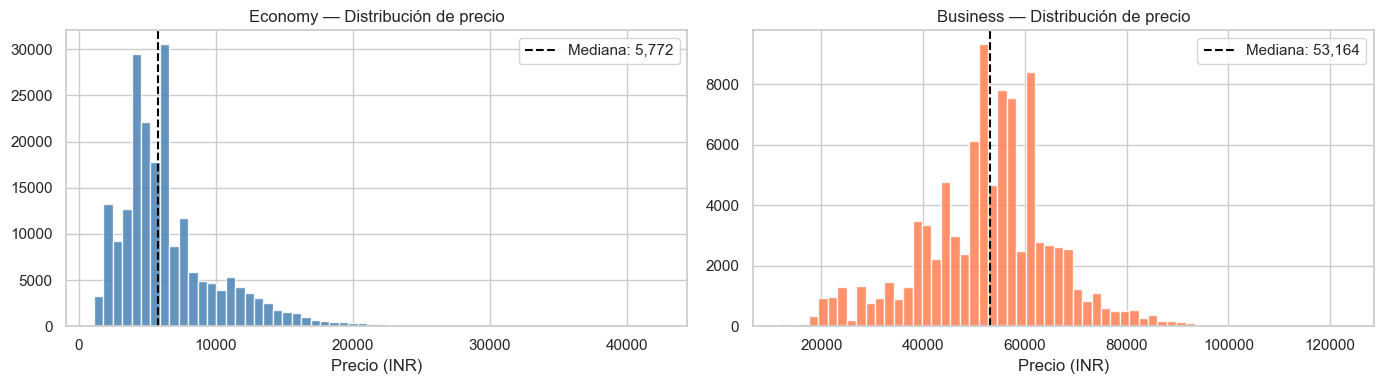

            min    50%   mean     max
class                                
Business 12,000 53,164 52,540 123,071
Economy   1,105  5,772  6,571  42,349


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, cls, color in zip(axes, ['Economy', 'Business'], ['steelblue', 'coral']):
    subset = df[df['class'] == cls]['price']
    ax.hist(subset, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{cls} — Distribución de precio')
    ax.set_xlabel('Precio (INR)')
    ax.axvline(subset.median(), color='black', linestyle='--', label=f'Mediana: {subset.median():,.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

print(df.groupby('class')['price'].describe()[['min','50%','mean','max']])

## 4. Precio por aerolínea

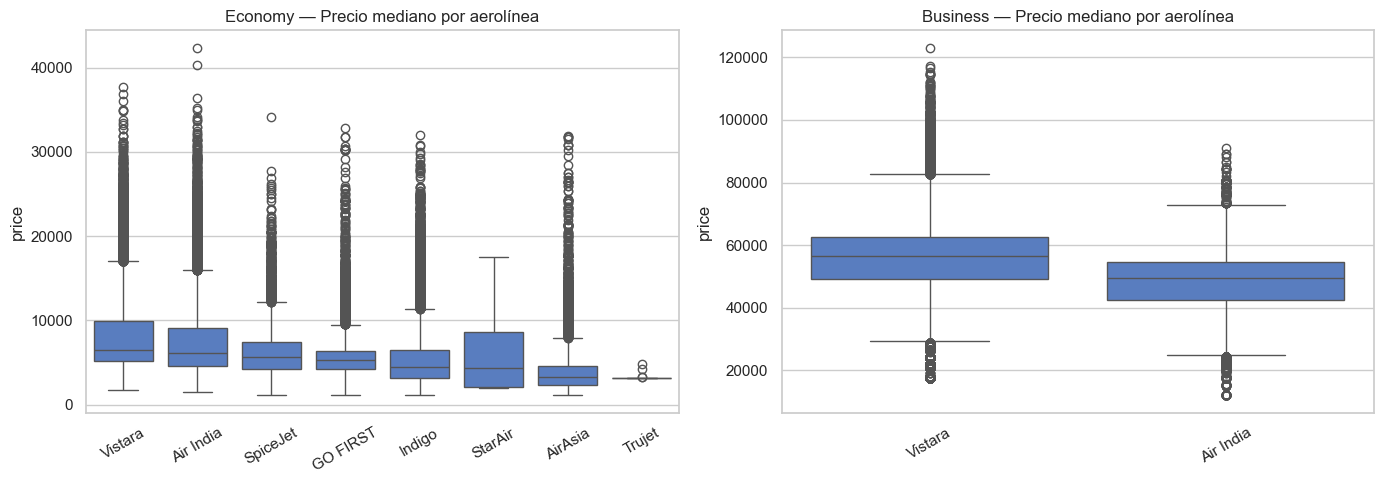

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cls in zip(axes, ['Economy', 'Business']):
    order = df[df['class']==cls].groupby('airline')['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df[df['class']==cls], x='airline', y='price', order=order, ax=ax)
    ax.set_title(f'{cls} — Precio mediano por aerolínea')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Precio por número de escalas

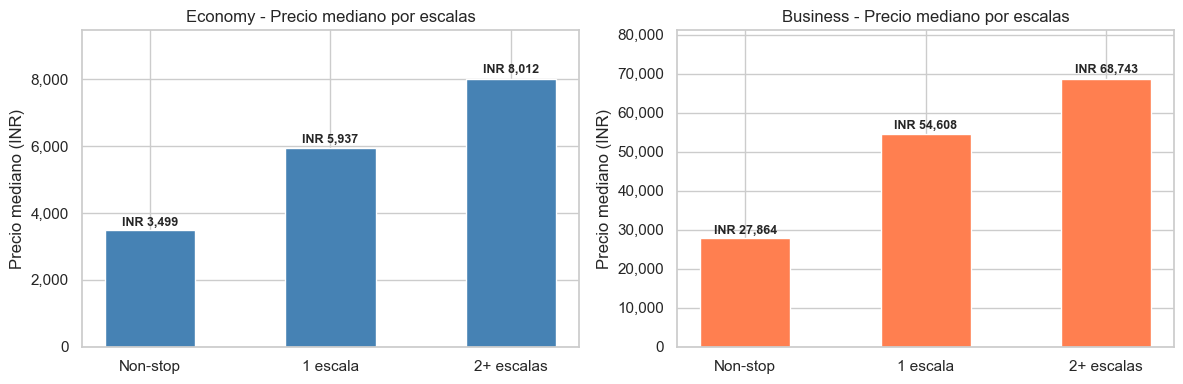

            Business  Economy Business/Economy
Escalas                                       
Non-stop      27,864    3,499             8.0x
1 escala      54,608    5,937             9.2x
2+ escalas    68,743    8,012             8.6x


In [16]:
import pandas as pd
_eco = pd.read_csv('../data/raw/economy.csv', encoding='utf-8-sig')
_bus = pd.read_csv('../data/raw/business.csv', encoding='utf-8-sig')
_eco['class'] = 'Economy'
_bus['class'] = 'Business'
_df = pd.concat([_eco, _bus], ignore_index=True)

stop_labels = {'non-stop': 'Non-stop', '1-stop': '1 escala', '2+-stop': '2+ escalas'}
stop_order  = ['non-stop', '1-stop', '2+-stop']

stop_clean  = _df['stop'].astype(str).str.extract(r'(non-stop|1-stop|2\+-stop)', expand=False)
price_clean = _df['price'].astype(str).str.replace(',', '', regex=False).astype(float)

stop_price = (
    _df.assign(sc=stop_clean, pc=price_clean)
    .groupby(['class', 'sc'])['pc']
    .median()
    .reset_index()
    .rename(columns={'sc': 'stop', 'pc': 'price'})
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, cls, color in zip(axes, ['Economy', 'Business'], ['steelblue', 'coral']):
    subset = (
        stop_price[stop_price['class'] == cls]
        .assign(order=lambda x: x['stop'].map({s: i for i, s in enumerate(stop_order)}))
        .sort_values('order')
    )
    vals   = list(subset['price'])
    labels = [stop_labels.get(s, s) for s in subset['stop']]
    bars = ax.bar(labels, vals, color=color, edgecolor='white', width=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + h*0.01,
                f'INR {h:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'{cls} - Precio mediano por escalas')
    ax.set_ylabel('Precio mediano (INR)')
    ax.set_ylim(0, max(vals) * 1.18)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

pivot = stop_price.pivot_table(index='stop', columns='class', values='price', aggfunc='median')
avail = [s for s in stop_order if s in pivot.index]
pivot = pivot.reindex(avail)
pivot.index = [stop_labels[s] for s in avail]
pivot.columns.name = None
pivot.index.name = 'Escalas'
pivot['Business/Economy'] = (pivot['Business'] / pivot['Economy']).map('{:.1f}x'.format)
print(pivot.to_string())

## 6. Precio vs duración del vuelo

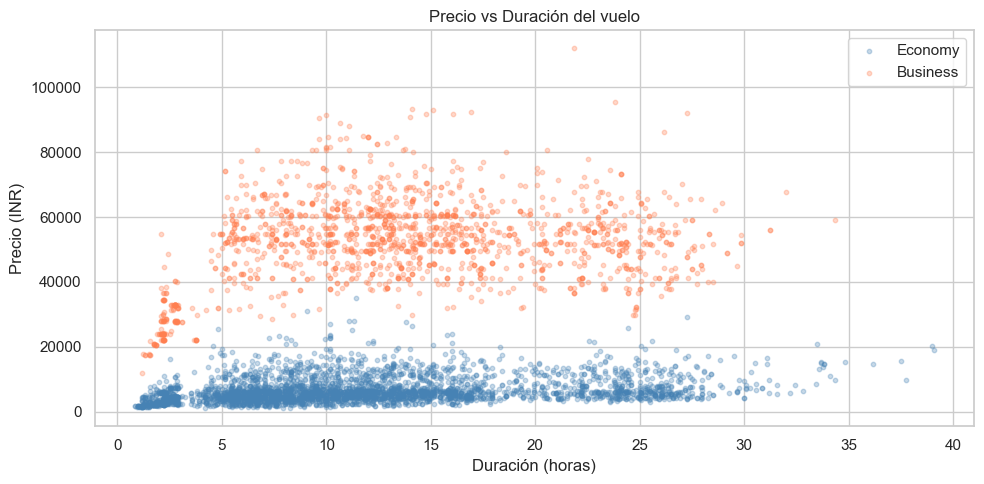

In [30]:
sample = df.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
for cls, color in [('Economy', 'steelblue'), ('Business', 'coral')]:
    s = sample[sample['class']==cls]
    ax.scatter(s['duration_hrs'], s['price'], alpha=0.3, s=10, color=color, label=cls)

ax.set_xlabel('Duración (horas)')
ax.set_ylabel('Precio (INR)')
ax.set_title('Precio vs Duración del vuelo')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Top 10 rutas más caras (Economy)

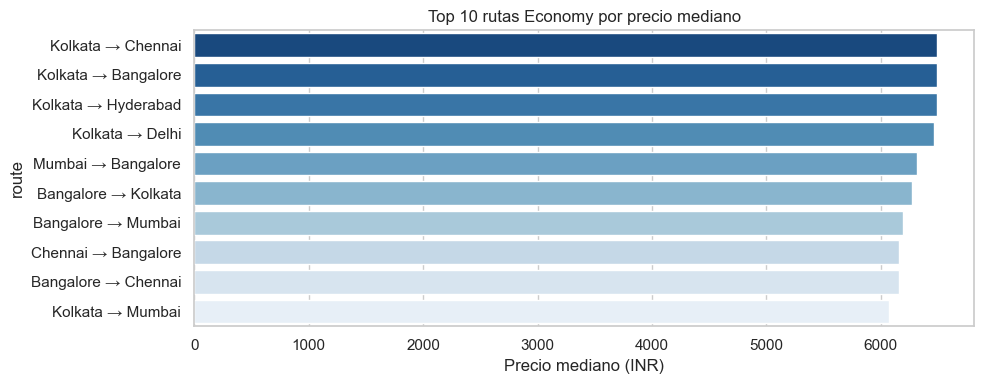

              route  median  count
  Kolkata → Chennai   6,489   4506
Kolkata → Bangalore   6,489   6894
Kolkata → Hyderabad   6,488   5555
    Kolkata → Delhi   6,461   7816
 Mumbai → Bangalore   6,319   8706
Bangalore → Kolkata   6,271   6888
 Bangalore → Mumbai   6,191   8744
Chennai → Bangalore   6,161   3962
Bangalore → Chennai   6,161   4117
   Kolkata → Mumbai   6,067   8103


In [31]:
df['route'] = df['from'] + ' → ' + df['to']

top_routes = (
    df[df['class']=='Economy']
    .groupby('route')['price']
    .agg(['median','count'])
    .query('count > 500')
    .sort_values('median', ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=top_routes, x='median', y='route', ax=ax, palette='Blues_r')
ax.set_title('Top 10 rutas Economy por precio mediano')
ax.set_xlabel('Precio mediano (INR)')
plt.tight_layout()
plt.show()

print(top_routes[['route','median','count']].to_string(index=False))

## 8. Precio por hora de salida

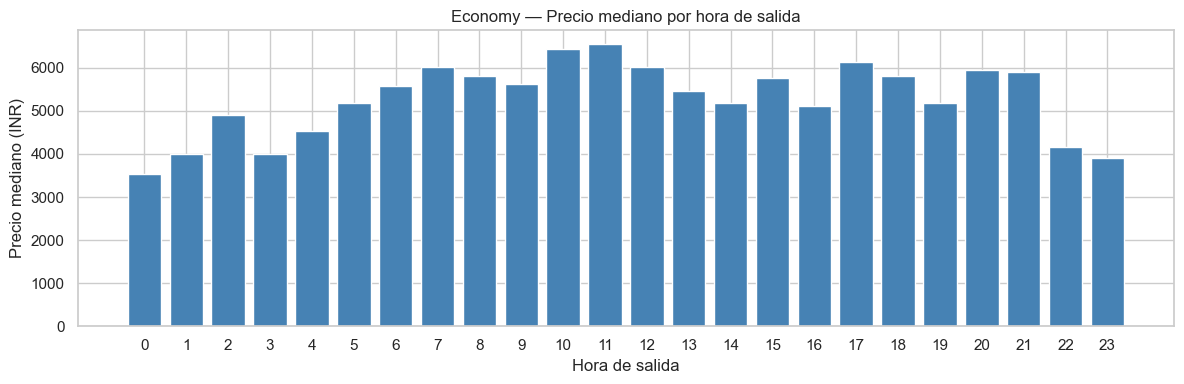

In [25]:
dep_price = df[df['class']=='Economy'].groupby('dep_hour')['price'].median().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(dep_price['dep_hour'], dep_price['price'], color='steelblue', edgecolor='white')
ax.set_title('Economy — Precio mediano por hora de salida')
ax.set_xlabel('Hora de salida')
ax.set_ylabel('Precio mediano (INR)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 9. Correlación con el precio (Economy)

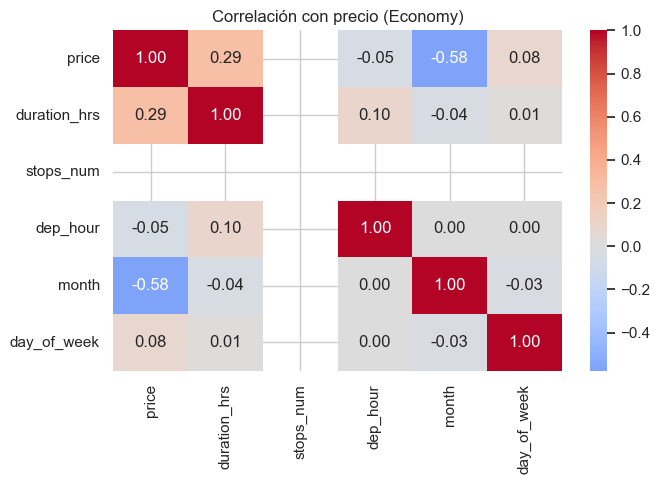

In [26]:
num_cols = ['price', 'duration_hrs', 'stops_num', 'dep_hour', 'month', 'day_of_week']
corr = df[df['class']=='Economy'][num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlación con precio (Economy)')
plt.tight_layout()
plt.show()

## 10. Insights clave

| # | Insight |
|---|---|
| 1 | Business cuesta en promedio **~5–6x** más que Economy en las mismas rutas |
| 2 | Los vuelos con **1 escala** no son necesariamente más baratos que non-stop — la ruta importa más |
| 3 | **Duración** tiene correlación moderada con precio en Economy (~0.4–0.5) |
| 4 | La **hora de salida** afecta el precio: vuelos madrugadores y nocturnos tienden a ser más baratos |
| 5 | El **mes** tiene variación — temporada alta visible en datos (marzo más caro que febrero) |

### Features para el modelo
- `duration_hrs` — continua
- `stops_num` — ordinal (0, 1, 2)
- `dep_hour` — cíclico (seno/coseno) o bins
- `month`, `day_of_week` — temporalidad
- `airline`, `from`, `to` — categóricas (label encoding o target encoding)
- `class` — binaria (0=Economy, 1=Business)